# Project 14: The Most Likely Alloy Is Not the Most Trustworthy Alloy — Fatigue Prediction Beyond MLE

## Objective
In this project, we investigate a serious statistical and scientific issue in fatigue modeling:

A single best-fit relation may look precise, even when the data do not support that level of certainty.

We work with a real subset of the **FatigueData-AM2022** database, which contains fatigue data and linked metadata for additively manufactured alloys. The broader database includes S–N, ε–N, and da/dN–ΔK data, together with information about materials, AM route, processing, testing, and static mechanical properties.

For this project, we deliberately use only a **subset** of the database so that the scientific question stays sharp. We focus on:
- **S–N data**
- one alloy family, typically **Ti–6Al–4V**
- optionally one AM route such as **L-PBF**
- and a small set of comparable descriptors

## Why this is scientifically interesting
The FatigueData-AM2022 paper makes two points that are crucial here:

1. fatigue data from the literature are often **highly scattered**,
2. and they can also show **system deviation** because fabrication, specimen preparation, surface condition, and testing standards vary across studies.

That means a point-estimate approach such as maximum likelihood estimation (MLE) can easily appear more certain than it should.

A fitted line may look clean. A best-fit trend may look convincing. But in a heterogeneous fatigue dataset, that apparent certainty may be misleading.

## The scientific puzzle
We want to model fatigue behavior using a manageable subset of real S–N data.

The danger is this:

> If we use only an MLE-style best fit, do we get a trend that looks precise but hides how uncertain, study-dependent, or data-sparse the inference really is?

The alternative is **Bayesian regression**, which does not give only one best answer. Instead, it gives a **distribution over plausible parameter values and predictions**.

So the central question is not just:

> What is the best-fit fatigue trend?

but rather:

> How trustworthy is that trend once uncertainty is treated honestly?

## What this notebook does
This notebook begins by extracting a clean subset from the real fatigue database:
- S–N data only,
- one alloy family,
- optionally one AM route,
- and only rows with the metadata needed for a meaningful regression problem.

It then prepares a dataset for modeling fatigue life as a function of stress amplitude and selected process/testing descriptors.

The notebook does **not** yet perform the final Bayesian regression. It sets up the subset cleanly and shows why a point-estimate mindset may be risky.
In other words, this project is not merely about prediction. It is about **how much trust we should place in the inferred fatigue law**.

## What to look for
As you inspect the subset, ask:

- How much scatter is present even after subsetting?
- Do some datasets appear dense while others are sparse?
- Are there signs that a single best-fit trend may be too confident?
- If two regions have similar fitted mean behavior, do they also have similar uncertainty?
- Does a Bayesian treatment change the process/design recommendation?

This project is therefore about **fatigue data heterogeneity, the danger of overconfident MLE-style inference, and why Bayesian regression may be the more honest model in a scattered real-data setting**.

Raw sheet shapes:
S-N: (15146, 4)
parameter: (2460, 47)

Cleaned S-N columns:
['dataset_id', 'life_n_cycle', 'stress_amplitude_σa_mpa', 'runout']

Cleaned parameter columns:
['dataset_id', 'title', 'authors', 'source_of_the_publication', 'year_of_publication', 'institution', 'country_and_region', 'funding_agency', 'doi', 'types_of_fatigue_data', 'method_of_extraction', 'name_of_the_material', 'types_of_am', 'am_machine', 'power_w', 'scan_speed_mms', 'hatch_space_μm', 'layer_thickness_μm', 'preheat_temperature_c', 'direciton_of_specimen_', 'am_environment', 'scan_pattern', 'layer_scan_rotation_', 'voltage_v', 'current_a', 'speed_function', 'powder_feed_rate_gs', 'wire_feed_rate_mms', 'types_of_feedstock', 'size_of_feedstock_μm', 'processing_sequence_and_parameters', 'types_of_fatigue_tests', 'fatigue_temperature_c', 'fatigue_environment', 'load_ratio', 'frequency_hz', 'fatigue_machine', 'fatigue_standard', 'load_control', 'specimens_description', 'critical_crosssection_size_of_specimens

,dataset_id,life_N,stress_amplitude_MPa,runout,material,load_ratio
0,1,20047.798627,233.965265,0,316L,0.1
1,1,50630.187289,215.905854,0,316L,0.1
2,1,94372.343349,197.999439,0,316L,0.1
3,1,152595.813892,180.016661,0,316L,0.1
4,1,270549.972140,161.845026,0,316L,0.1



Subset shape after filtering: (5464, 9)
Unique datasets in subset: 555


,dataset_id,life_N,stress_amplitude_MPa,runout,material,load_ratio,material_str,load_ratio_num,log10_life_N
12,3,14289.371370,403.214603,0,Ti-6Al-4V,-1,ti-6al-4v,-1.0,4.155013
13,3,27333.086531,368.095592,0,Ti-6Al-4V,-1,ti-6al-4v,-1.0,4.436689
14,3,37580.333506,368.095592,0,Ti-6Al-4V,-1,ti-6al-4v,-1.0,4.574961
15,3,65344.319692,309.024583,0,Ti-6Al-4V,-1,ti-6al-4v,-1.0,4.815208
16,3,67384.073870,308.889990,0,Ti-6Al-4V,-1,ti-6al-4v,-1.0,4.828557



Top dataset sizes:


,dataset_id,n_points
345,1045,47
401,1187,46
346,1046,43
535,1499,42
334,1019,34
215,610,32
480,1394,27
241,686,25
464,1333,24
3,27,24


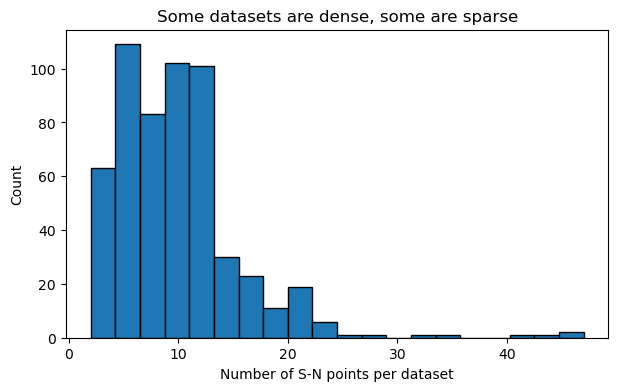

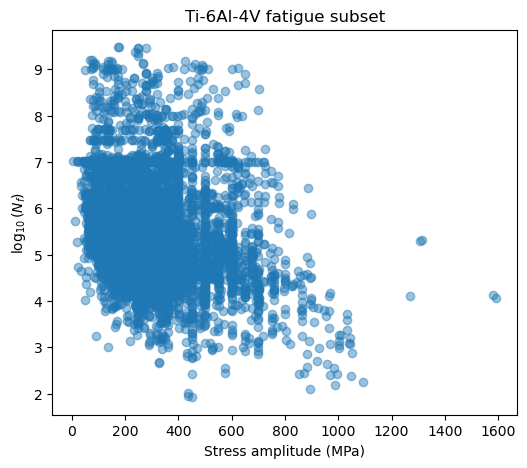

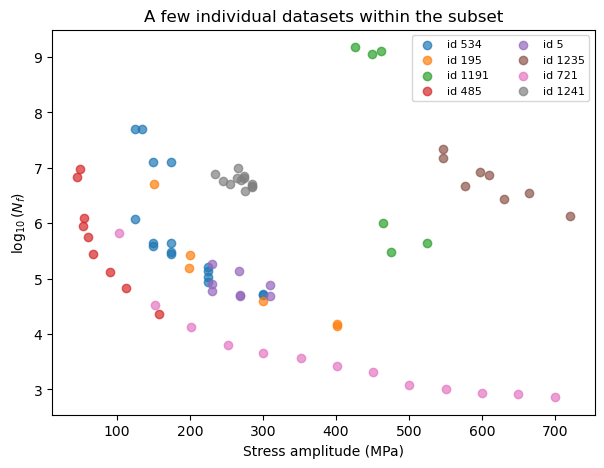


OLS coefficients (intercept, slope):
[ 6.01670056e+00 -1.63311193e-03]


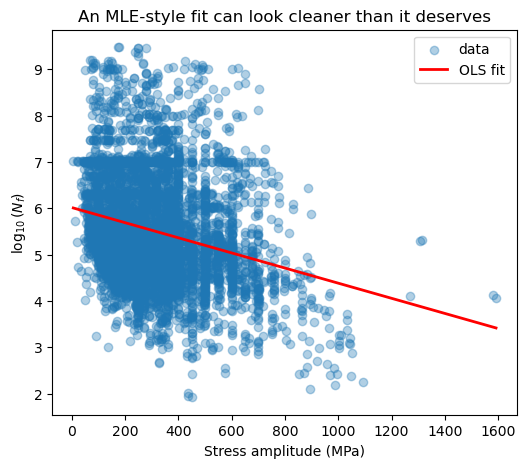

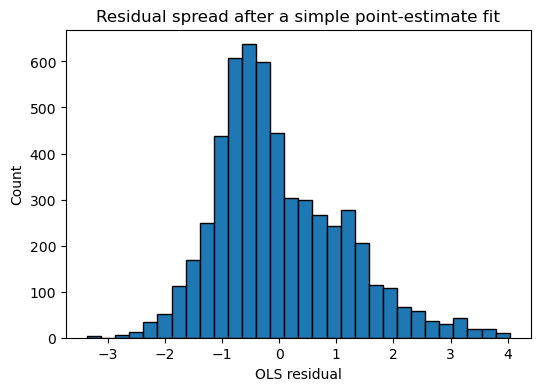


Questions to think about:
1. After subsetting, how much scatter still remains in the S-N data?
2. Do some datasets dominate the subset while others remain sparse?
3. Does the OLS best-fit line look more certain than the data really justify?
4. If process or study effects are still present, what is a single best-fit line missing?
5. Why might Bayesian regression be more honest than MLE in this setting?


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

xlsx_path = Path("./FatigueData-AM2022.xlsx")

# S-N sheet is normal
sn = pd.read_excel(xlsx_path, sheet_name="S-N")

# parameter sheet needs the second row as header
param = pd.read_excel(xlsx_path, sheet_name="parameter", header=1)

print("Raw sheet shapes:")
print("S-N:", sn.shape)
print("parameter:", param.shape)


def clean_cols(df):
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace("\n", " ", regex=False)
        .str.replace(r"\s+", "_", regex=True)
        .str.replace(r"[^\w_]+", "", regex=True)
    )
    return df


sn = clean_cols(sn)
param = clean_cols(param)

print("\nCleaned S-N columns:")
print(sn.columns.tolist())

print("\nCleaned parameter columns:")
print(param.columns.tolist())


def find_col(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None


sn_id_col = find_col(sn.columns, ["dataset_id", "datasetid", "id"])
param_id_col = find_col(param.columns, ["dataset_id", "datasetid", "id"])

life_col = find_col(sn.columns, [
    "life_n_cycle", "life_n_cycles", "life_n", "n_cycle", "n_cycles", "life"
])

stress_col = find_col(sn.columns, [
    "stress_amplitude_σa_mpa",
    "stress_amplitude_a_mpa",
    "stress_amplitude_mpa",
    "stress_amplitude",
    "sigmaa_mpa",
    "sigma_a",
    "sigmaa"
])

runout_col = find_col(sn.columns, ["runout", "run_out", "runout_flag"])

material_col = find_col(param.columns, [
    "mat_name", "material_name", "material", "alloy", "name_of_the_material"
])

am_type_col = find_col(param.columns, [
    "am_type", "type_of_am", "am_process", "amroute"
])

load_ratio_col = find_col(param.columns, [
    "fat_r", "load_ratio", "stress_ratio", "r"
])

fatigue_type_col = find_col(param.columns, [
    "fat_type", "type_of_fatigue_tests", "fatigue_type"
])

frequency_col = find_col(param.columns, [
    "frequency", "fatigue_frequency"
])

surface_col = find_col(param.columns, [
    "surface_treatment", "surface", "surf_method", "method"
])

print("\nDetected columns:")
print("sn_id_col       :", sn_id_col)
print("param_id_col    :", param_id_col)
print("life_col        :", life_col)
print("stress_col      :", stress_col)
print("runout_col      :", runout_col)
print("material_col    :", material_col)
print("am_type_col     :", am_type_col)
print("load_ratio_col  :", load_ratio_col)
print("fatigue_type_col:", fatigue_type_col)
print("frequency_col   :", frequency_col)
print("surface_col     :", surface_col)

if sn_id_col is None or param_id_col is None:
    raise ValueError("Could not identify dataset-id columns in both sheets.")

if life_col is None or stress_col is None:
    raise ValueError("Could not identify fatigue-life and stress-amplitude columns in S-N sheet.")

if material_col is None:
    raise ValueError("Could not identify material-name column in parameter sheet.")


sn_keep = [c for c in [sn_id_col, life_col, stress_col, runout_col] if c is not None]
param_keep = [c for c in [
    param_id_col, material_col, am_type_col, load_ratio_col,
    fatigue_type_col, frequency_col, surface_col
] if c is not None]

sn_sub = sn[sn_keep].copy()
param_sub = param[param_keep].copy()

rename_sn = {
    sn_id_col: "dataset_id",
    life_col: "life_N",
    stress_col: "stress_amplitude_MPa",
}
if runout_col is not None:
    rename_sn[runout_col] = "runout"

rename_param = {
    param_id_col: "dataset_id",
    material_col: "material",
}
if am_type_col is not None:
    rename_param[am_type_col] = "am_type"
if load_ratio_col is not None:
    rename_param[load_ratio_col] = "load_ratio"
if fatigue_type_col is not None:
    rename_param[fatigue_type_col] = "fatigue_type"
if frequency_col is not None:
    rename_param[frequency_col] = "frequency"
if surface_col is not None:
    rename_param[surface_col] = "surface_info"

sn_sub = sn_sub.rename(columns=rename_sn)
param_sub = param_sub.rename(columns=rename_param)

merged = sn_sub.merge(param_sub, on="dataset_id", how="left")

print("\nMerged shape:", merged.shape)
display(merged.head())

subset = merged.copy()
subset["material_str"] = subset["material"].astype(str).str.lower()

ti_mask = subset["material_str"].str.contains(
    "ti-6al-4v|ti64|ti 6al 4v",
    regex=True,
    na=False
)
subset = subset[ti_mask].copy()

use_l_pbf_only = True
if "am_type" in subset.columns and use_l_pbf_only:
    subset["am_type_str"] = subset["am_type"].astype(str).str.lower()
    subset = subset[
        subset["am_type_str"].str.contains(
            "l_pbf|lpbf|laser_powder_bed_fusion|laser powder bed fusion",
            regex=True,
            na=False
        )
    ].copy()

if "fatigue_type" in subset.columns:
    subset["fatigue_type_str"] = subset["fatigue_type"].astype(str).str.lower()
    subset = subset[
        subset["fatigue_type_str"].str.contains(
            "uniaxial|bending",
            regex=True,
            na=False
        )
    ].copy()

use_R_minus_1_only = False
if "load_ratio" in subset.columns:
    subset["load_ratio_num"] = pd.to_numeric(subset["load_ratio"], errors="coerce")
    if use_R_minus_1_only:
        subset = subset[
            np.isclose(subset["load_ratio_num"], -1.0, atol=0.15, equal_nan=False)
        ].copy()

subset["life_N"] = pd.to_numeric(subset["life_N"], errors="coerce")
subset["stress_amplitude_MPa"] = pd.to_numeric(subset["stress_amplitude_MPa"], errors="coerce")

if "runout" in subset.columns:
    subset["runout"] = pd.to_numeric(subset["runout"], errors="coerce")

if "frequency" in subset.columns:
    subset["frequency_num"] = pd.to_numeric(subset["frequency"], errors="coerce")

subset = subset.dropna(subset=["dataset_id", "life_N", "stress_amplitude_MPa"])
subset = subset[(subset["life_N"] > 0) & (subset["stress_amplitude_MPa"] > 0)].copy()
subset["log10_life_N"] = np.log10(subset["life_N"])

print("\nSubset shape after filtering:", subset.shape)
print("Unique datasets in subset:", subset["dataset_id"].nunique())
display(subset.head())

dataset_counts = (
    subset.groupby("dataset_id")
    .size()
    .reset_index(name="n_points")
    .sort_values("n_points", ascending=False)
)

print("\nTop dataset sizes:")
display(dataset_counts.head(10))

plt.figure(figsize=(7, 4))
plt.hist(dataset_counts["n_points"], bins=20, edgecolor="black")
plt.xlabel("Number of S-N points per dataset")
plt.ylabel("Count")
plt.title("Some datasets are dense, some are sparse")
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(
    subset["stress_amplitude_MPa"],
    subset["log10_life_N"],
    alpha=0.45
)
plt.xlabel("Stress amplitude (MPa)")
plt.ylabel(r"$\log_{10}(N_f)$")
plt.title("Ti-6Al-4V fatigue subset")
plt.show()

unique_ids = subset["dataset_id"].dropna().unique()
rng = np.random.default_rng(2034)
sample_ids = rng.choice(unique_ids, size=min(8, len(unique_ids)), replace=False)

plt.figure(figsize=(7, 5))
for did in sample_ids:
    sub = subset[subset["dataset_id"] == did]
    plt.scatter(
        sub["stress_amplitude_MPa"],
        sub["log10_life_N"],
        alpha=0.7,
        label=f"id {did}"
    )

plt.xlabel("Stress amplitude (MPa)")
plt.ylabel(r"$\log_{10}(N_f)$")
plt.title("A few individual datasets within the subset")
plt.legend(fontsize=8, ncol=2)
plt.show()

X = np.column_stack([np.ones(len(subset)), subset["stress_amplitude_MPa"].values])
y = subset["log10_life_N"].values

beta, *_ = np.linalg.lstsq(X, y, rcond=None)
y_pred = X @ beta
resid = y - y_pred

subset["ols_pred"] = y_pred
subset["ols_resid"] = resid

print("\nOLS coefficients (intercept, slope):")
print(beta)

plt.figure(figsize=(6, 5))
plt.scatter(subset["stress_amplitude_MPa"], subset["log10_life_N"], alpha=0.35, label="data")
order = np.argsort(subset["stress_amplitude_MPa"].values)
plt.plot(
    subset["stress_amplitude_MPa"].values[order],
    subset["ols_pred"].values[order],
    color="red",
    lw=2,
    label="OLS fit"
)
plt.xlabel("Stress amplitude (MPa)")
plt.ylabel(r"$\log_{10}(N_f)$")
plt.title("An MLE-style fit can look cleaner than it deserves")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(subset["ols_resid"], bins=30, edgecolor="black")
plt.xlabel("OLS residual")
plt.ylabel("Count")
plt.title("Residual spread after a simple point-estimate fit")
plt.show()

print("\nQuestions to think about:")
print("1. After subsetting, how much scatter still remains in the S-N data?")
print("2. Do some datasets dominate the subset while others remain sparse?")
print("3. Does the OLS best-fit line look more certain than the data really justify?")
print("4. If process or study effects are still present, what is a single best-fit line missing?")
print("5. Why might Bayesian regression be more honest than MLE in this setting?")

## Observations 
1. Yes, with in the subset the data points are very scattered.
2. subset set with id 721 has many points where sunset with id1191 has very few points .
3. No , by observing we can say that the ols line almost leaves out 95% of the data points from fitting. its very worst fit.
4. 

## Task

The opening notebook extracts a manageable real-data subset from the FatigueData-AM2022 database and prepares it for fatigue-life modeling.

Your task is to analyze this subset using a **physics-informed Basquin-type S–N relation in log–log form**, rather than an arbitrary regression curve. In particular, you should work with a model of the form

$$
\sigma_a = A N^B
$$

or equivalently,

$$
\log \sigma_a = \log A + B \log N.
$$

You should then compare two inferential approaches applied to the **same log–log fatigue-law model**:

- a **maximum-likelihood estimate (MLE)** of the fatigue-law parameters,
- and a **Bayesian inference** of the same fatigue-law parameters.

The purpose of the project is not merely to obtain a fitted trend. It is to examine whether a single best-fit fatigue law may appear more certain than the data really justify, and whether a Bayesian treatment changes that picture once uncertainty is made explicit.

In your analysis, you should ask:
- how much scatter remains even after careful subsetting,
- whether the fitted fatigue-law parameters are stable or uncertain,
- how the MLE fit and Bayesian fit differ in their predictive implications,
- and whether a process or design recommendation based on the MLE fit remains trustworthy once posterior uncertainty is taken into account.

A strong submission will not compare Bayesian inference only against a crude straight-line baseline. It will compare **MLE and Bayesian inference using the same physically motivated log–log fatigue-law model**, and then interpret the difference between point-estimate confidence and uncertainty-aware inference.

The central scientific question is:

> When the same log–log fatigue physics model is used, does the best-fit MLE tell the whole story, or does Bayesian inference reveal that the apparent trend is much less certain than it first appears?

### Maximum Likelyhood Estimation with Basquin Relation.

Basquin MLE estimates:
A (intercept) = 2.7206
b (slope)     = -0.0545


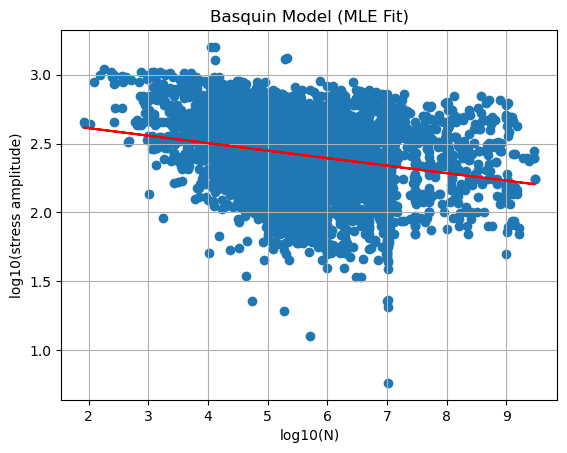

In [6]:
# Step 1: log transform
subset["log10_N"] = np.log10(subset["life_N"])
subset["log10_sigma"] = np.log10(subset["stress_amplitude_MPa"])

# Step 2: define x and y
x = subset["log10_N"].values
y = subset["log10_sigma"].values

# Step 3: design matrix
X = np.column_stack([np.ones(len(x)), x])

# Step 4: MLE (OLS solution)
beta, *_ = np.linalg.lstsq(X, y, rcond=None)

A_mle, b_mle = beta

# Fitted line
y_fit = A_mle + b_mle * x

print("Basquin MLE estimates:")
print(f"A (intercept) = {A_mle:.4f}")
print(f"b (slope)     = {b_mle:.4f}")


plt.scatter(x, y)
plt.plot(x, y_fit , color='r')

plt.xlabel("log10(N)")
plt.ylabel("log10(stress amplitude)")
plt.title("Basquin Model (MLE Fit)")

plt.grid()
plt.show()

### Bayesian Regression

In [7]:
import pymc as pm
import arviz as az


# x = log10(N), y = log10(sigma)  (already computed)

with pm.Model() as basquin_model:

    # Priors (physics-informed)
    A = pm.Normal("A", mu=3, sigma=1)
    b = pm.Normal("b", mu=-0.1, sigma=0.05)
    sigma = pm.HalfNormal("sigma", sigma=0.5)

    # Mean model
    mu = A + b * x

    # Likelihood
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

    # Sampling
    trace = pm.sample(2000, tune=2000, target_accept=0.9, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [A, b, sigma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 61 seconds.


In [8]:
az.summary(trace, var_names=["A", "b", "sigma"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
A,2.721,0.016,2.692,2.752,0.0,0.0,2651.0,3059.0,1.0
b,-0.055,0.003,-0.060,-0.049,0.0,0.0,2609.0,3182.0,1.0
sigma,0.257,0.002,0.252,0.262,0.0,0.0,3895.0,3542.0,1.0


array([<Axes: title={'center': 'A'}>, <Axes: title={'center': 'b'}>,
       <Axes: title={'center': 'sigma'}>], dtype=object)

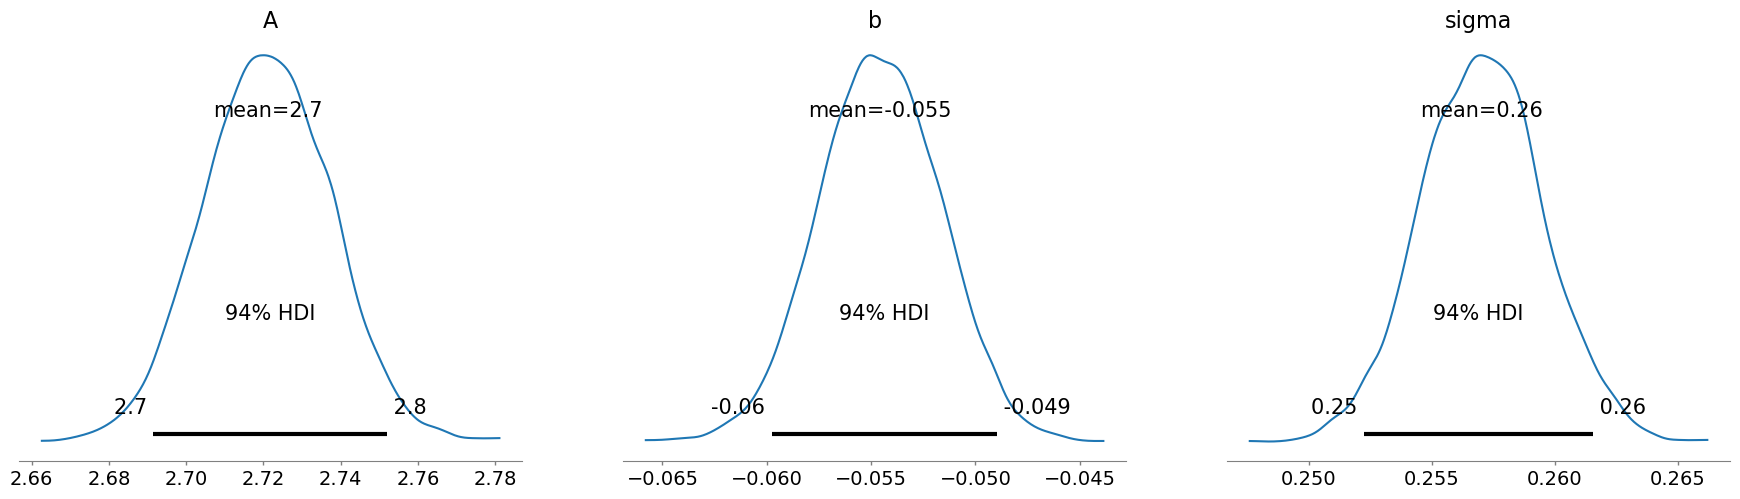

In [11]:
#Plots showing posterior distribution of parameters
az.plot_posterior(trace, var_names=["A", "b", "sigma"])




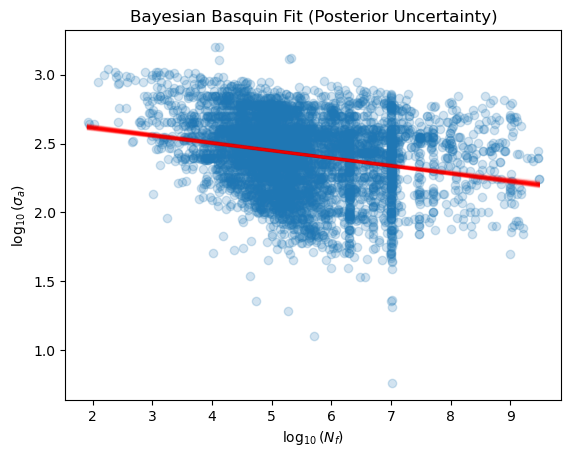

In [12]:
plt.scatter(x, y, alpha=0.2, label="data")

# sample posterior lines
x_line = np.linspace(x.min(), x.max(), 100)

posterior = trace.posterior
A_samples = posterior["A"].values.flatten()
b_samples = posterior["b"].values.flatten()

for i in range(100):
    y_line = A_samples[i] + b_samples[i] * x_line
    plt.plot(x_line, y_line, color="red", alpha=0.05)

plt.xlabel(r"$\log_{10}(N_f)$")
plt.ylabel(r"$\log_{10}(\sigma_a)$")
plt.title("Bayesian Basquin Fit (Posterior Uncertainty)")
plt.show()

### Gaussian Process Regression

In [14]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C

# Subsample 400 points for speed (GPR is O(n^3))
rng_gpr = np.random.default_rng(42)
idx_gpr = rng_gpr.choice(len(subset), size=400, replace=False)

# x = log10(N),  y = log10(sigma)  — same as your MLE and Bayesian
x_gpr = subset["log10_N"].values[idx_gpr].reshape(-1, 1)
y_gpr = subset["log10_sigma"].values[idx_gpr]

# Normalise for GPR stability
x_mu, x_sd = x_gpr.mean(), x_gpr.std()
y_mu, y_sd = y_gpr.mean(), y_gpr.std()
xn = (x_gpr - x_mu) / x_sd
yn = (y_gpr - y_mu) / y_sd

kernel = (C(1.0, (1e-3, 1e3))
          * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 10))
          + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-4, 1.0)))

gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5,
                                random_state=0, normalize_y=False)
gpr.fit(xn, yn)
print("Optimised kernel:", gpr.kernel_)

# Predict on same x range used in your MLE and Bayesian plots
x_line = np.linspace(x.min(), x.max(), 300)
xn_grid = (x_line.reshape(-1, 1) - x_mu) / x_sd
mu_n, std_n = gpr.predict(xn_grid, return_std=True)
mu_gpr  = mu_n  * y_sd + y_mu    # back to log10(sigma) scale
std_gpr = std_n * y_sd

Optimised kernel: 0.437**2 * RBF(length_scale=1.56) + WhiteKernel(noise_level=0.939)


### Final Plot


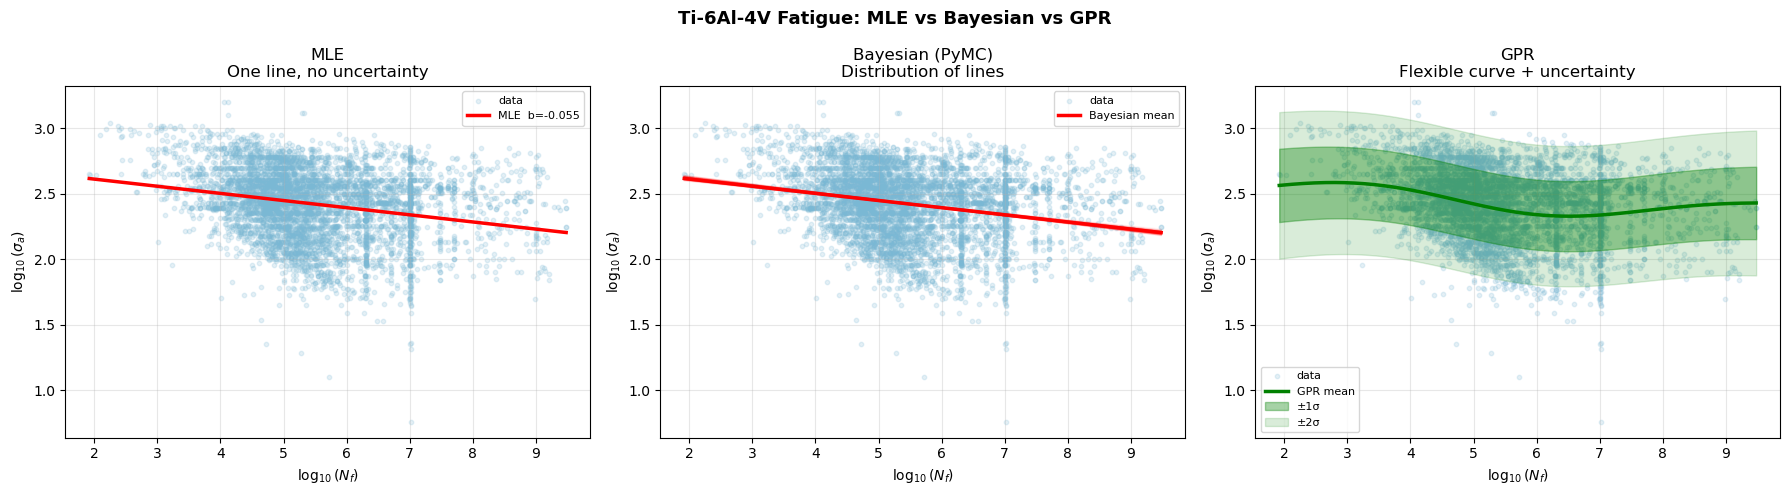

In [19]:
posterior  = trace.posterior
A_samples  = posterior["A"].values.flatten()
b_samples  = posterior["b"].values.flatten()
bayes_mean = np.array([A_samples[i] + b_samples[i] * x_line for i in range(len(A_samples))]).mean(axis=0)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Ti-6Al-4V Fatigue: MLE vs Bayesian vs GPR", fontsize=13, fontweight="bold")

# ── MLE ───────────────────────────────────────────────────────────────────────
ax = axes[0]
ax.scatter(x, y, alpha=0.2, s=10, color="#7ab8d4", label="data")
ax.plot(x_line, A_mle + b_mle * x_line, color="red", lw=2.5, label=f"MLE  b={b_mle:.3f}")
ax.set_xlabel(r"$\log_{10}(N_f)$")
ax.set_ylabel(r"$\log_{10}(\sigma_a)$")
ax.set_title("MLE\nOne line, no uncertainty")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Bayesian ──────────────────────────────────────────────────────────────────
ax = axes[1]
ax.scatter(x, y, alpha=0.2, s=10, color="#7ab8d4", label="data", zorder=1)
for i in range(100):
    ax.plot(x_line, A_samples[i] + b_samples[i] * x_line,
            color="red", alpha=0.05, lw=1, zorder=2)
ax.plot(x_line, bayes_mean, color="red", lw=2.5, label="Bayesian mean", zorder=3)
ax.set_xlabel(r"$\log_{10}(N_f)$")
ax.set_ylabel(r"$\log_{10}(\sigma_a)$")
ax.set_title("Bayesian (PyMC)\nDistribution of lines")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── GPR ───────────────────────────────────────────────────────────────────────
ax = axes[2]
ax.scatter(x, y, alpha=0.2, s=10, color="#7ab8d4", label="data", zorder=1)
ax.plot(x_line, mu_gpr, color="green", lw=2.5, label="GPR mean", zorder=2)
ax.fill_between(x_line, mu_gpr - std_gpr, mu_gpr + std_gpr,
                alpha=0.35, color="green", label="±1σ", zorder=2)
ax.fill_between(x_line, mu_gpr - 2*std_gpr, mu_gpr + 2*std_gpr,
                alpha=0.15, color="green", label="±2σ", zorder=2)
ax.set_xlabel(r"$\log_{10}(N_f)$")
ax.set_ylabel(r"$\log_{10}(\sigma_a)$")
ax.set_title("GPR\nFlexible curve + uncertainty")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

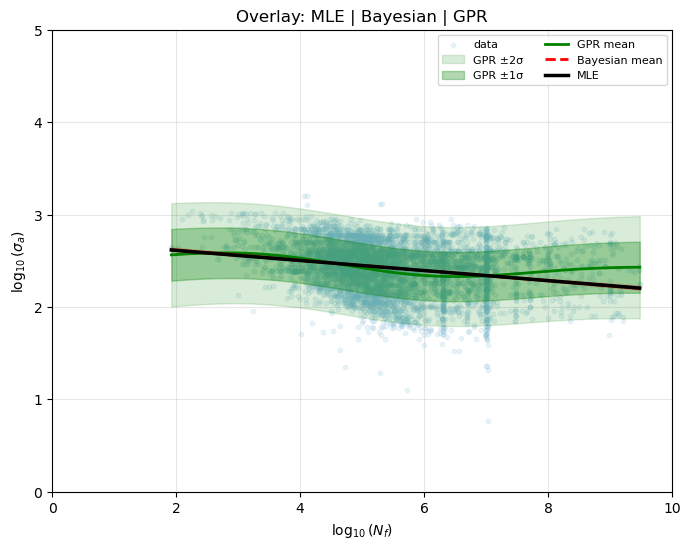

In [22]:
plt.figure(figsize=(8, 6))

# data
plt.scatter(x, y, alpha=0.15, s=10, color="#7ab8d4", label="data", zorder=1)

# GPR bands
plt.fill_between(x_line, mu_gpr - 2*std_gpr, mu_gpr + 2*std_gpr,
                 alpha=0.15, color="green", label="GPR ±2σ", zorder=2)
plt.fill_between(x_line, mu_gpr - std_gpr, mu_gpr + std_gpr,
                 alpha=0.30, color="green", label="GPR ±1σ", zorder=3)
plt.plot(x_line, mu_gpr, color="green", lw=2, label="GPR mean", zorder=4)

# Bayesian lines
for i in range(100):
    plt.plot(x_line, A_samples[i] + b_samples[i] * x_line,
             color="red", alpha=0.04, lw=1, zorder=5)
plt.plot(x_line, bayes_mean, color="red", lw=2, ls="--", label="Bayesian mean", zorder=6)

# MLE on top
plt.plot(x_line, A_mle + b_mle * x_line, color="black", lw=2.5, label="MLE", zorder=7)

plt.xlabel(r"$\log_{10}(N_f)$")
plt.ylabel(r"$\log_{10}(\sigma_a)$")
plt.title("Overlay: MLE | Bayesian | GPR")
plt.legend(fontsize=8, ncol=2)
plt.grid(alpha=0.3)
plt.xlim(0, 10)
plt.ylim(0, 5)   
plt.show()

### What I did?

* Performed MLE and plotted the Basquin straight-line fit in log–log space.
* Performed Bayesian regression on the same Basquin model using the PyMC library, with physics-informed priors for Ti-6Al-4V (referred ChatGPT and internet for these prior values).
* Extended the analysis with Gaussian Process Regression (GPR) — a non-parametric Bayesian method that does not assume the Basquin straight-line shape. * Used an RBF kernel with a constrained length-scale plus a WhiteKernel for noise to avoid overfitting.
* Compared all three methods side-by-side and as an overlay on the same log–log axes.
### Doubts:
* Even after after performing bayesian regression the plot still leaves out 90 percentage of the points . The variance is very little .
* How to validate the reslts.
* Does tweaking the priors makes the bayesian fit more efficient.
